In [197]:
import pandas as pd
import numpy as np
from nbconvert import export
from itertools import combinations


In [198]:
#Loading in the roads data file
df1 = pd.read_csv('./data/_roads3.csv')

# print(df1.head())

#Filtering on only the N1 road
roads = ['N1', 'N2'] + [f'N{i}' for i in range(100, 300)]

dfN = df1[df1['road'].isin(roads)]
# dfN['road'].value_counts()


In [199]:
#Creating the source and sink for the new data frame, based on the minimal and maximal chainage
source_rows = dfN.loc[dfN.groupby('road')['chainage'].idxmin()]
sink_rows = dfN.loc[dfN.groupby('road')['chainage'].idxmax()]

df_proc = (
    pd.concat([source_rows, sink_rows])
    .drop_duplicates(subset=['road', 'chainage', 'lrp'])
    .sort_values(['road', 'chainage'])
    .reset_index(drop=True)
)

df_proc


,road,chainage,lrp,lat,lon,gap,type,name
0,N1,0.000,LRPS,23.706028,90.443333,NaN,Others,Start of Road after Jatrabari Flyover infront...
1,N1,462.254,LRPE,20.862917,92.298083,NaN,Others,"End of Road at Shapla Chattar ,Teknaf Meet wit..."
2,N101,0.000,LRPS,23.454139,91.212861,NaN,Others,Start of Road from N120 at Balutopa
3,N101,6.021,LRPE,23.459306,91.253389,NaN,Others,End of road Bibir bazar Bridge
4,N102,0.000,LRPS,23.478972,91.118194,NaN,Others,Start of road from N1 Mainamati
5,N102,82.682,LRPE,24.050611,91.114667,NaN,Others,Meet with N 2 at Sanail
6,N103,0.000,LRPS,23.957028,91.115528,NaN,Others,Road start from N102 at Kuatali.
7,N103,4.779,LRPE,23.996889,91.109278,NaN,Others,Intersection with N102 at Ghaturia.
8,N104,0.000,LRPS,23.009667,91.399416,NaN,Others,Intersection with Z1031
9,N104,49.630,LRPE,22.825749,91.101444,NaN,Others,Meet with Z1441& Z1405 at Sonapur.


In [200]:
df_proc['total_length'] = df_proc.groupby('road')['chainage'].transform('max')

df_filtered = (df_proc[df_proc['total_length'] > 25]).copy()
# df_filtered.drop('total_length', axis=1, inplace=True))
display(df_filtered.head())
df_filtered.road.value_counts()

,road,chainage,lrp,lat,lon,gap,type,name,total_length
0,N1,0.000,LRPS,23.706028,90.443333,NaN,Others,Start of Road after Jatrabari Flyover infront...,462.254
1,N1,462.254,LRPE,20.862917,92.298083,NaN,Others,"End of Road at Shapla Chattar ,Teknaf Meet wit...",462.254
4,N102,0.000,LRPS,23.478972,91.118194,NaN,Others,Start of road from N1 Mainamati,82.682
5,N102,82.682,LRPE,24.050611,91.114667,NaN,Others,Meet with N 2 at Sanail,82.682
8,N104,0.000,LRPS,23.009667,91.399416,NaN,Others,Intersection with Z1031,49.630


road
N1      2
N102    2
N104    2
N105    2
N106    2
N2      2
N204    2
N207    2
N208    2
Name: count, dtype: int64

In [201]:
df_filtered['model_type'] = 'sourcesink'
df_filtered['length'] = 0
df_filtered['condition'] = None

df_filtered = df_filtered[['road', 'lrp', 'model_type', 'name', 'lat', 'lon', 'length', 'condition', 'chainage']]
df_filtered.rename(columns={'lrp': 'id'}, inplace=True)

df_filtered

,road,id,model_type,name,lat,lon,length,condition,chainage
0,N1,LRPS,sourcesink,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0,None,0.000
1,N1,LRPE,sourcesink,"End of Road at Shapla Chattar ,Teknaf Meet wit...",20.862917,92.298083,0,None,462.254
4,N102,LRPS,sourcesink,Start of road from N1 Mainamati,23.478972,91.118194,0,None,0.000
5,N102,LRPE,sourcesink,Meet with N 2 at Sanail,24.050611,91.114667,0,None,82.682
8,N104,LRPS,sourcesink,Intersection with Z1031,23.009667,91.399416,0,None,0.000
9,N104,LRPE,sourcesink,Meet with Z1441& Z1405 at Sonapur.,22.825749,91.101444,0,None,49.630
10,N105,LRPS,sourcesink,"Starts of road from N1,Dhaka teknaf road at Ma...",23.690416,90.546611,0,None,0.000
11,N105,LRP048,sourcesink,"B.Bridge 83 km,Tangail 60 km / End of Road In...",23.989527,90.358222,0,None,48.870
12,N106,LRPS,sourcesink,Start of Road from Oxygen More,22.393555,91.821583,0,None,0.000
13,N106,LRPE,sourcesink,The road ends Infront of DC Bunglow,22.648527,92.201833,0,None,66.850


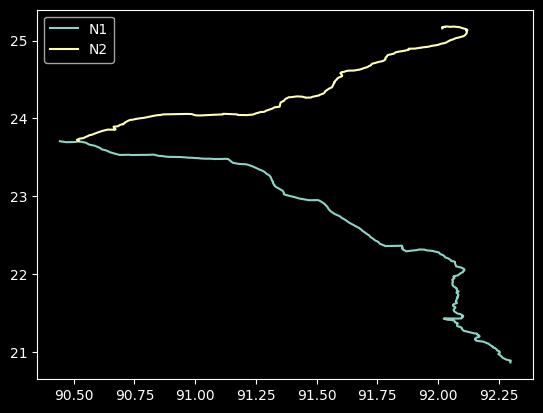

In [202]:
# Visual inspection of N1 and N2
import matplotlib.pyplot as plt

df_plot = dfN[dfN['road'].isin(['N1', 'N2'])]

for road, data in df_plot.groupby('road'):
    plt.plot(data['lon'], data['lat'], label=road)

plt.legend()
plt.show()

In [203]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

    return R * c

In [204]:
df_n1 = dfN[dfN['road'] == 'N1'].copy()
df_n2 = dfN[dfN['road'] == 'N2'].copy()

df_cross = df_n1.merge(df_n2, how='cross', suffixes=('_n1', '_n2'))

df_cross['distance'] = haversine(
    df_cross['lat_n1'],
    df_cross['lon_n1'],
    df_cross['lat_n2'],
    df_cross['lon_n2']
)

intersections = df_cross[df_cross['distance'] < 0.05]

intersections[['road_n1','chainage_n1','lrp_n1',
               'road_n2','chainage_n2','lrp_n2',
               'distance']]



,road_n1,chainage_n1,lrp_n1,road_n2,chainage_n2,lrp_n2,distance
15062,N1,8.763,LRP009a,N2,0.0,LRPS,0.020374


In [205]:
roads = df_filtered['road'].unique()
road_pairs = list(combinations(roads, 2))


In [206]:
all_intersections = []

for r1, r2 in road_pairs:

    df_r1 = dfN[dfN['road'] == r1]
    df_r2 = dfN[dfN['road'] == r2]

    df_cross = df_r1.merge(df_r2, how='cross', suffixes=('_1', '_2'))

    df_cross['distance'] = haversine(
        df_cross['lat_1'],
        df_cross['lon_1'],
        df_cross['lat_2'],
        df_cross['lon_2']
    )

    inter = df_cross[df_cross['distance'] < 0.05]

    all_intersections.append(inter)

intersections = pd.concat(all_intersections, ignore_index=True)
intersections[['road_1','chainage_1','lrp_1',
               'road_2','chainage_2','lrp_2',
               'distance']]


,road_1,chainage_1,lrp_1,road_2,chainage_2,lrp_2,distance
0,N1,81.801,LRP083a,N102,0.000,LRPS,0.048258
1,N1,81.829,LRP084,N102,0.000,LRPS,0.019837
2,N1,81.846,LRP084a,N102,0.000,LRPS,0.002835
3,N1,145.409,LRP148a,N104,1.878,LRP001a,0.009078
4,N1,11.936,LRP012c,N105,0.000,LRPS,0.002831
5,N1,8.763,LRP009a,N2,0.000,LRPS,0.020374
6,N102,82.682,LRPE,N2,85.823,LRP086a,0.033466
7,N105,12.803,LRP012a,N2,11.464,LRP012a,0.029759
8,N105,12.803,LRP012a,N2,11.476,LRP012b,0.023229
9,N105,12.803,LRP012a,N2,11.517,LRP012c,0.037868


In [207]:
df_i1 = intersections[['road_1','lrp_1','chainage_1']].rename(columns={
    'road_1':'road',
    'lrp_1':'lrp',
    'chainage_1':'chainage'
})

df_i2 = intersections[['road_2','lrp_2','chainage_2']].rename(columns={
    'road_2':'road',
    'lrp_2':'lrp',
    'chainage_2':'chainage'
})

df_intersections = pd.concat([df_i1, df_i2]).drop_duplicates()
# display(df_intersections)

df_intersections = df_intersections.merge(
    dfN,
    on=['road','lrp','chainage'],
    how='left'
)
# print(df_intersections.head())

df_intersections['model_type'] = 'intersection'
df_intersections['length'] = 0
df_intersections['condition'] = None

df_intersections = df_intersections[['road','lrp','model_type','name','lat','lon','length','condition','chainage']]
df_intersections = df_intersections.rename(columns={'lrp':'id'})

df_final = pd.concat([df_filtered, df_intersections], ignore_index=True)
df_final = df_final.sort_values(['road', 'chainage']).reset_index(drop=True)
df_final.head(50)

,road,id,model_type,name,lat,lon,length,condition,chainage
0,N1,LRPS,sourcesink,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0,None,0.000
1,N1,LRP009a,intersection,Road to Sylhet (N2),23.706083,90.521527,0,None,8.763
2,N1,LRP012c,intersection,Right to Syedpur (R113) left to Joydebpur N105),23.690416,90.546583,0,None,11.936
3,N1,LRP083a,intersection,Box culvert,23.478944,91.117722,0,None,81.801
4,N1,LRP084,intersection,Km post missing,23.478972,91.117999,0,None,81.829
5,N1,LRP084a,intersection,Road to Brahmanbaria(N102),23.478972,91.118166,0,None,81.846
6,N1,LRP148a,intersection,Intersection with N104 / Km post missing,23.009556,91.381360,0,None,145.409
7,N1,LRPE,sourcesink,"End of Road at Shapla Chattar ,Teknaf Meet wit...",20.862917,92.298083,0,None,462.254
8,N102,LRPS,sourcesink,Start of road from N1 Mainamati,23.478972,91.118194,0,None,0.000
9,N102,LRPS,intersection,Start of road from N1 Mainamati,23.478972,91.118194,0,None,0.000


Hier moeten we nog even een stukje code schrijven die checkt of alle intersection er nu voor beide wegen in staan en die ook dezelfde id's geeft, of misschien een kolom toevoegen met iets waar we met het toewijzen van index dan weer naar kunnen kijken en dan een if statement omheen kunnen bouwen

In [208]:
#Loading in the Bridges data
df_BMMS = pd.read_excel('./data/BMMS_overview.xlsx')

#Selecting the columns that we need
cols = [
    "road",
    "name",
    "LRPName",
    "length",
    "chainage",
    "lat",
    "lon",
    "condition",
]

bridges_BMMS = df_BMMS[cols].copy()

roads = df_filtered['road'].unique()
bridges_BMMS = bridges_BMMS[bridges_BMMS['road'].isin(roads)]

bridges_BMMS['name_clean'] = bridges_BMMS['name'].astype(str).str.replace(' ', '').str.upper()

display(bridges_BMMS.head(20))


,road,name,LRPName,length,chainage,lat,lon,condition,name_clean
0,N1,.,LRP001a,11.30,1.800,23.698739,90.458861,A,.
1,N1,.,LRP004b,6.60,4.925,23.694664,90.487775,A,.
2,N1,Kanch pur Bridge.,LRP008b,394.23,8.976,23.705060,90.523214,A,KANCHPURBRIDGE.
3,N1,NOYAPARA CULVERT,LRP010b,6.30,10.880,23.694391,90.537574,A,NOYAPARACULVERT
4,N1,ADUPUR CULVERT,LRP010c,6.30,10.897,23.694302,90.537707,A,ADUPURCULVERT
5,N1,NAYABARI KASPUR BOX CULVERT,LRP011a,8.30,11.296,23.692360,90.540918,A,NAYABARIKASPURBOXCULVERT
6,N1,KHAS PARA BOX CULVERT,LRP012a,9.30,12.239,23.688412,90.548559,A,KHASPARABOXCULVERT
7,N1,DAWAN BAG BOX CULVERT,LRP012b,6.10,12.253,23.688320,90.548650,A,DAWANBAGBOXCULVERT
8,N1,Madanpur Bridge.(L),LRP013a,27.50,12.660,23.685583,90.551208,A,MADANPURBRIDGE.(L)
9,N1,MADAN PUR (R),LRP013a,26.30,12.660,23.685583,90.551208,A,MADANPUR(R)


In [209]:
#Dropping duplicates
df_unique = bridges_BMMS.drop_duplicates(
    subset=['chainage','lat','lon'],
    keep='first'
).reset_index(drop=True)

#Filtering on bridges only
df_unique['model_type'] = 'bridge'

df_bridges = df_unique[['road','LRPName','model_type','name','lat','lon','length','condition','chainage']]

df_bridges = df_bridges.rename(columns={'LRPName':'id'})

df_final = pd.concat([df_final, df_bridges], ignore_index=True)

df_final = df_final.sort_values(['road','chainage']).reset_index(drop=True)

df_final = (
    df_final
    .assign(
        prefix=(
            df_final["name"]
            .str.replace('.', '')
            .str.lower()
            .str.strip()
            .str.extract(r"^([^(]+)", expand=False)
        )
    )
    .drop_duplicates(subset=['road','prefix'], keep='first')
    .drop(columns="prefix")
)

df_final.head(20)


,road,id,model_type,name,lat,lon,length,condition,chainage
0,N1,LRPS,sourcesink,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0.00,None,0.000
1,N1,LRP001a,bridge,.,23.698739,90.458861,11.30,A,1.800
3,N1,LRP009a,intersection,Road to Sylhet (N2),23.706083,90.521527,0.00,None,8.763
4,N1,LRP008b,bridge,Kanch pur Bridge.,23.705060,90.523214,394.23,A,8.976
5,N1,LRP010a,bridge,KATCHPUR BOX CULVERT,23.696400,90.535099,8.00,B,10.543
6,N1,LRP010b,bridge,NOYAPARA CULVERT,23.694391,90.537574,6.30,A,10.880
7,N1,LRP010c,bridge,ADUPUR CULVERT,23.694302,90.537707,6.30,A,10.897
8,N1,LRP011a,bridge,NAYABARI KASPUR BOX CULVERT,23.692360,90.540918,8.30,A,11.296
9,N1,LRP011c,bridge,NAYABARI BOX CULVERT,23.690912,90.545462,10.60,B,11.808
10,N1,LRP012c,intersection,Right to Syedpur (R113) left to Joydebpur N105),23.690416,90.546583,0.00,None,11.936


In [210]:
final_df_with_links = []

for road, road_df in df_final.groupby('road'):

    road_df = road_df.sort_values('chainage').reset_index(drop=True)

    for j in range(len(road_df)):
        row = road_df.iloc[j]

        # eerste node (source)
        if j == 0:
            final_df_with_links.append(row)
            continue

        prev = road_df.iloc[j-1]

        # link locatie (midden van de twee nodes)
        lat_link = (row['lat'] + prev['lat']) / 2
        lon_link = (row['lon'] + prev['lon']) / 2

        # length of the road
        link_length = (row['chainage'] - prev['chainage']) * 1000

        link = {
            'road': road,
            'id': None,
            'model_type': 'link',
            'name': 'Link',
            'lat': lat_link,
            'lon': lon_link,
            'length': link_length,
            'condition': None,
            'chainage': (row['chainage'] + prev['chainage']) / 2 #wat gebeurt hier precies, gaat dit goed
        }

        final_df_with_links.append(pd.Series(link))
        final_df_with_links.append(row)

final_df_with_links = pd.DataFrame(final_df_with_links).reset_index(drop=True)

final_df_with_links.head(20)

,road,id,model_type,name,lat,lon,length,condition,chainage
0,N1,LRPS,sourcesink,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0.00,None,0.0000
1,N1,None,link,Link,23.702383,90.451097,1800.00,None,0.9000
2,N1,LRP001a,bridge,.,23.698739,90.458861,11.30,A,1.8000
3,N1,None,link,Link,23.702411,90.490194,6963.00,None,5.2815
4,N1,LRP009a,intersection,Road to Sylhet (N2),23.706083,90.521527,0.00,None,8.7630
5,N1,None,link,Link,23.705572,90.522371,213.00,None,8.8695
6,N1,LRP008b,bridge,Kanch pur Bridge.,23.705060,90.523214,394.23,A,8.9760
7,N1,None,link,Link,23.700730,90.529157,1567.00,None,9.7595
8,N1,LRP010a,bridge,KATCHPUR BOX CULVERT,23.696400,90.535099,8.00,B,10.5430
9,N1,None,link,Link,23.695395,90.536337,337.00,None,10.7115


In [211]:
intersection_length = 20  # meters

final_df_with_links.loc[
    final_df_with_links['model_type'] == 'intersection',
    'length'
] = intersection_length

In [212]:
for i in range(1, len(final_df_with_links)-1):

    if final_df_with_links.loc[i, 'model_type'] == 'link':

        prev_len = final_df_with_links.loc[i-1, 'length']
        next_len = final_df_with_links.loc[i+1, 'length']

        final_df_with_links.loc[i, 'length'] = (
            final_df_with_links.loc[i, 'length']
            - prev_len/2
            - next_len/2
        )

final_df_with_links.head()

,road,id,model_type,name,lat,lon,length,condition,chainage
0,N1,LRPS,sourcesink,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0.00,None,0.0000
1,N1,None,link,Link,23.702383,90.451097,1794.35,None,0.9000
2,N1,LRP001a,bridge,.,23.698739,90.458861,11.30,A,1.8000
3,N1,None,link,Link,23.702411,90.490194,6947.35,None,5.2815
4,N1,LRP009a,intersection,Road to Sylhet (N2),23.706083,90.521527,20.00,None,8.7630


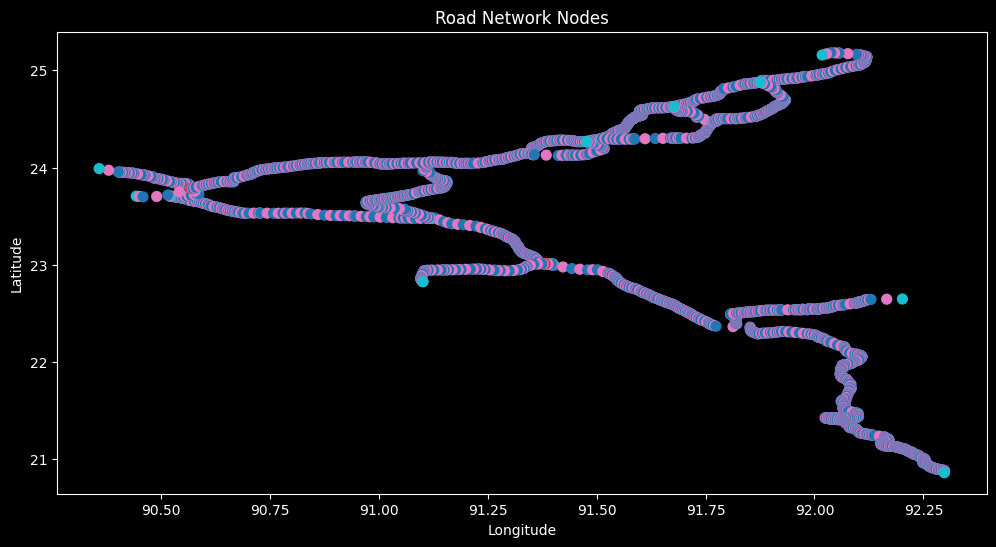

In [218]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# kleur automatisch per model_type
colors = final_df_with_links['model_type'].astype('category').cat.codes

plt.scatter(
    final_df_with_links['lon'],
    final_df_with_links['lat'],
    c=colors,
    cmap='tab10',   # mooie colormap
    s=50
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Road Network Nodes')

plt.show()

In [213]:
# #Adding all bridges to final dataframe
# final_df = pd.DataFrame(columns=['road', 'id', 'model_type', 'name', 'lat', 'lon', 'length', 'condition', 'chainage'])
#
# final_df = pd.concat([source, export_df, sink], ignore_index=True)
# final_df = final_df.sort_values('chainage').reset_index(drop=True)
# final_df
# #Filtering the names in final_df with the help of a regex function that processes the string until the first '('. If after replacing dots, lowercase and strip, the names are exactly the same for two bridges, the bridge is treated as duplicate and is deleted.
# final_df = (
#     final_df
#     .assign(
#         prefix=(
#             final_df["name"]
#             .str.replace('.', '')
#             .str.lower()
#             .str.strip()
#             .str.extract(r"^([^(]+)", expand=False)
#         )
#     )
#     .drop_duplicates(subset="prefix", keep="first")
#     .drop(columns="prefix")
# )
#
# final_df.head(20)

In [214]:
#     #Adding the links in between the bridges. Their exact locations do not matter and are calculated based on the location of the pre- and succeeding bridge. The length of the link does matter, and is calculated based on the chainage of the two bridges it lies in between.
# final_df_with_links = []
#
# for j in range(len(final_df)):
#     row = final_df.iloc[j]
#
#     if row['model_type'] == 'source':
#         final_df_with_links.append(row)
#         continue
#
#     if row['model_type'] == 'sink':
#         final_df_with_links.append(row)
#         break
#
#     prev = final_df.iloc[j - 1]
#
#     lat_link = (row['lat'] + prev['lat']) / 2
#     lon_link = (row['lon'] + prev['lon']) / 2
#
#     link_length = (row['chainage'] - prev['chainage']) * 1000  #Because chainage is in km
#
#     link = {
#         'road': row['road'],
#         'id': None,
#         'model_type': 'link',
#         'name': 'Link',
#         'lat': lat_link,
#         'lon': lon_link,
#         'length': link_length,
#         'condition': None,
#         'chainage': (row['chainage'] + prev['chainage']) / 2
#     }
#
#     final_df_with_links.append(pd.Series(link))
#     final_df_with_links.append(row)
#
# final_df_with_links = (
#     pd.DataFrame(final_df_with_links)
#     .reset_index(drop=True)
#     .drop(columns='chainage')
# )
#
# final_df_with_links['id'] = 100000 + (final_df_with_links.index + 1)
#
# final_df_with_links.head(20)